In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from BERTopic_model import run_BERTopic_model
import random

random.seed(1234)

# Dataloading
df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_advice_fulltext.csv"))
docs = list(df["text"])
docs = [doc.replace('\xa0', '') for doc in docs]
classes = list(df["gen"])

base_param_dic = {
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "n_neighbors": 15,
    "n_components": 10,
    "min_dist": 0.0,
    "min_cluster_size": 20,
    "min_df": 3,
    "max_df": 1.0,
    "ngram_range": (1, 3),
    "top_n_words": 5,
    "seed": 0
}



topic_model = run_BERTopic_model(base_param_dic, docs)
topic_model.get_topic_info()

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-05-16 14:01:47,452 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-16 14:02:03,493 - BERTopic - Dimensionality - Completed ✓
2025-05-16 14:02:03,494 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-16 14:02:03,589 - BERTopic - Cluster - Completed ✓
2025-05-16 14:02:03,594 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-05-16 14:02:10,623 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,181,-1_gnome_gnomes_mushrooms_round,"[gnome, gnomes, mushrooms, round, try]","[gnomes, gnome, number mushrooms, red basket, ...","[gnomes, number mushrooms, colours, mushroom, ...",[There are 2 teams of gnomes - The yellow bask...
1,0,201,0_gnome_points_gnomes_colour,"[gnome, points, gnomes, colour, hat]","[colour gnomes, colour gnome, points gnomes, g...","[colour gnomes, colour gnome, points gnomes, g...",[I'm not sure that there is a set definite cho...
2,1,143,1_mushrooms_gnome_gnomes_colour,"[mushrooms, gnome, gnomes, colour, try]","[gnomes mushrooms, gnome mushrooms, number mus...","[gnomes mushrooms, gnome mushrooms, number mus...",[You will be shown two coloured gnomes and tak...
3,2,143,2_basket_red_yellow_mushrooms,"[basket, red, yellow, mushrooms, gnomes]","[gnomes yellow basket, gnomes red basket, bask...","[gnomes yellow basket, gnomes red basket, bask...",[There are two different colours of baskets in...
4,3,98,3_points_blue_colours_pink,"[points, blue, colours, pink, purple]","[certain colours, pick colour, colours, colors...","[certain colours, pick colour, colors, blue gr...",[It is said that certain colours score higher ...
5,4,76,4_basket_red_baskets_yellow,"[basket, red, baskets, yellow, points]","[gnomes baskets, basket colours, colour basket...","[gnomes baskets, basket colours, baskets red y...",[On the screen you will be presented with two ...
6,5,73,5_mushrooms_colours_mushroom_gives,"[mushrooms, colours, mushroom, gives, change]","[colour gives mushrooms, colours mushrooms, mu...","[colour gives mushrooms, colours mushrooms, mu...",[Pay attention to which mushroom person gives ...
7,6,34,6_hats_tall_hat_taller,"[hats, tall, hat, taller, tall hats]","[hat colour, short yellow hat, tall hats, shor...","[hat colour, short yellow hat, tall hats, shor...",[The taller hats seem to pay out best but it i...
8,7,28,7_keys_just_breaks_fingers,"[keys, just, breaks, fingers, game]","[press keys, fingers keys, keyboard, stay focu...","[press keys, fingers keys, stay focused, play,...",[You really just have to go with your intuitio...
9,8,23,8_forest_mushrooms_gnomes_green,"[forest, mushrooms, gnomes, green, orange]","[gnomes mushrooms, mushrooms gnomes, mushrooms...","[mushrooms gnomes, mushrooms forest, mushrooms...","[There are two forests. Green, orange, yellow,..."


Save model for later use

In [2]:
topic_model.save(os.path.join(os.path.dirname(os.getcwd()), "results", "BERTopic_model"), serialization="safetensors", save_ctfidf=True, save_embedding_model="all-MiniLM-L6-v2")

In [3]:
topic_distr, _ = topic_model.approximate_distribution(docs)
df_stat = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_stake.csv"))

for topic_n in range(len(topic_distr[0,:])):
    topic_name = "topic_" + str(topic_n)
    df_stat[topic_name] = topic_distr[:, topic_n]

df_stat["assigned_topic"] = topic_model.topics_

100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


In [4]:
parent_topic_weight = []
var_names = [f'topic_{n}' for n in range(len(topic_distr[0, :]))]

for i in range(len(df_stat["ID"])):
    parent_ID = df_stat["parent_ID"][i]
    parent_row = df_stat[df_stat["ID"] == parent_ID]
    if len(parent_row) < 1:
        parent_topic_weight.append([None for n in range(len(topic_distr[0, :]))])
    else:
        res = parent_row[var_names].values.tolist()
        parent_topic_weight.append(res[0])

parent_topic_df = pd.DataFrame(parent_topic_weight)
parent_topic_df.columns = [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

df_stat = pd.concat([df_stat, parent_topic_df], axis=1)
df_stat = df_stat.loc[:, ~df_stat.columns.str.contains('^Unnamed')]
df_stat.tail(2)

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,gen,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
998,668d5331aa58b7e75ff160d7,0.091113,0.161720,0.020506,0.714286,63,234906_experiment_2024-07-10_19h00.46.327.csv,0.609375,"The taller gnomes perform better, yellow is th...",10,...,0,0.221088,0.106216,0.178365,0.245181,0.127053,0.000000,0.089415,0.032682,0.000000
999,668d822d705c807ed4664ae1,0.820187,0.642993,0.997381,2.688492,5,564113_experiment_2024-07-10_18h59.42.430.csv,0.730469,There are two types of baskets RED or YELLOWRe...,10,...,2,0.033895,0.121273,0.322428,0.065764,0.263046,0.090508,0.015138,0.003036,0.084913


In [5]:
var_names = ["score_corrected", "pl2_understanding", "pl1_understanding"] + [f'topic_{n}' for n in range(len(topic_distr[0, :]))] + [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

cor_table = df_stat[var_names].corr()
cor_table

,score_corrected,pl2_understanding,pl1_understanding,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,...,topic_8,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
score_corrected,1.000000,0.455890,0.164747,-0.165547,-0.148440,0.350854,-0.025915,0.340409,-0.082576,-0.131103,...,0.187982,-0.130815,-0.118024,0.302520,-0.068447,0.277862,-0.104595,-0.126849,-0.162206,0.166144
pl2_understanding,0.455890,1.000000,0.042760,-0.267743,-0.206230,0.605975,-0.179855,0.551340,-0.193668,-0.173490,...,0.217541,-0.302156,-0.196534,0.549951,-0.169839,0.493924,-0.170416,-0.176694,-0.167276,0.138323
pl1_understanding,0.164747,0.042760,1.000000,0.031361,0.036259,0.056900,0.064106,0.037306,0.004619,-0.081235,...,0.058654,0.083142,0.067987,-0.068463,0.049440,-0.021813,0.079188,-0.037989,-0.075747,-0.029427
topic_0,-0.165547,-0.267743,0.031361,1.000000,0.093666,-0.307544,0.086105,-0.081061,-0.340894,0.029938,...,-0.214431,0.322132,0.128025,-0.216706,0.070062,-0.166029,-0.007703,0.058520,-0.054220,-0.061915
topic_1,-0.148440,-0.206230,0.036259,0.093666,1.000000,-0.194565,-0.427200,-0.376704,0.349623,-0.180750,...,0.076056,0.175700,0.380595,-0.206924,-0.146907,-0.201624,0.187743,-0.062588,-0.053932,-0.005806
topic_2,0.350854,0.605975,0.056900,-0.307544,-0.194565,1.000000,-0.198857,0.777806,-0.321773,-0.279553,...,0.150818,-0.265131,-0.228516,0.640212,-0.119434,0.584815,-0.239373,-0.195872,-0.222705,0.036630
topic_3,-0.025915,-0.179855,0.064106,0.086105,-0.427200,-0.198857,1.000000,-0.035437,-0.116066,-0.022446,...,-0.131968,0.019815,-0.140589,-0.122705,0.315271,-0.103147,0.007183,-0.049522,0.040857,-0.048835
topic_4,0.340409,0.551340,0.037306,-0.081061,-0.376704,0.777806,-0.035437,1.000000,-0.420850,-0.272657,...,-0.005613,-0.201669,-0.249654,0.584146,-0.083617,0.588104,-0.218119,-0.198213,-0.211210,-0.025471
topic_5,-0.082576,-0.193668,0.004619,-0.340894,0.349623,-0.321773,-0.116066,-0.420850,1.000000,-0.144267,...,-0.034440,-0.025924,0.217631,-0.195367,-0.016352,-0.189806,0.306626,-0.086901,0.005289,-0.018847
topic_6,-0.131103,-0.173490,-0.081235,0.029938,-0.180750,-0.279553,-0.022446,-0.272657,-0.144267,1.000000,...,-0.217163,0.108852,-0.058488,-0.188779,0.002875,-0.185542,-0.070358,0.546466,-0.049821,-0.119396


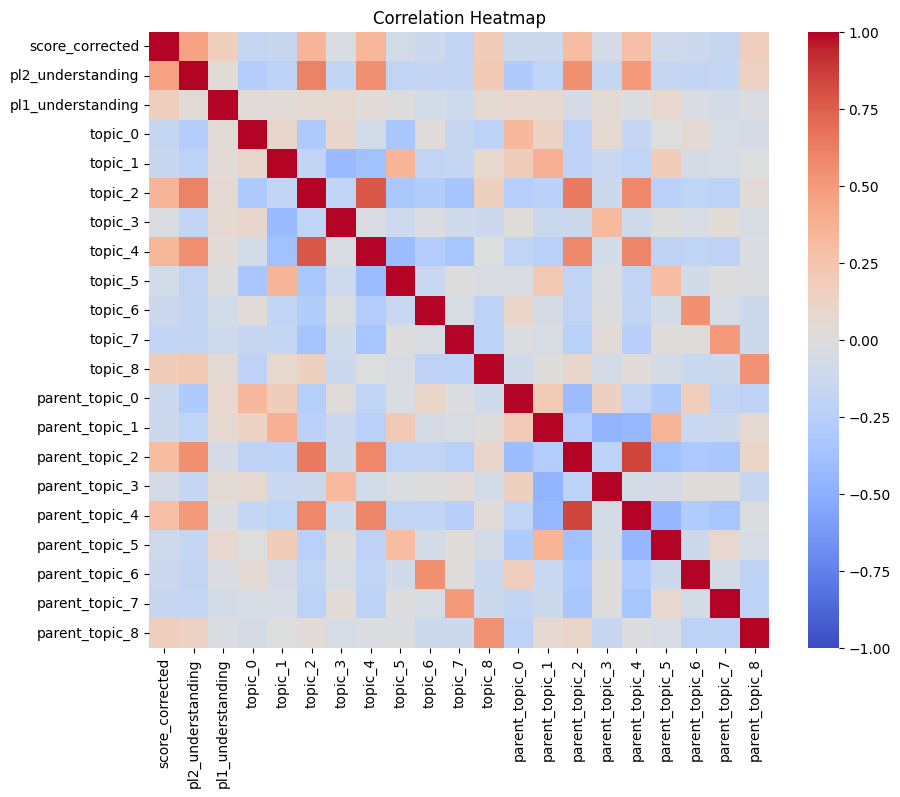

In [6]:
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_table, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

Output

In [7]:
df_stat.to_csv(os.path.join(os.path.dirname(os.getcwd()), "results", "docs_topic_weights.csv"), header=True, index=False)

## Visualization

In [8]:
topic_model.visualize_topics(use_ctfidf=True)

In [9]:
topic_model.visualize_hierarchy()

In [10]:
topic_model.visualize_heatmap(use_ctfidf=True)

In [51]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,181,-1_gnome_gnomes_mushrooms_round,"[gnome, gnomes, mushrooms, round, try]","[gnomes, gnome, number mushrooms, red basket, ...","[gnomes, number mushrooms, colours, mushroom, ...",[There are 2 teams of gnomes - The yellow bask...
1,0,201,0_gnome_points_gnomes_colour,"[gnome, points, gnomes, colour, hat]","[colour gnomes, colour gnome, points gnomes, g...","[colour gnomes, colour gnome, points gnomes, g...",[I'm not sure that there is a set definite cho...
2,1,143,1_mushrooms_gnome_gnomes_colour,"[mushrooms, gnome, gnomes, colour, try]","[gnomes mushrooms, gnome mushrooms, number mus...","[gnomes mushrooms, gnome mushrooms, number mus...",[You will be shown two coloured gnomes and tak...
3,2,143,2_basket_red_yellow_mushrooms,"[basket, red, yellow, mushrooms, gnomes]","[gnomes yellow basket, gnomes red basket, bask...","[gnomes yellow basket, gnomes red basket, bask...",[There are two different colours of baskets in...
4,3,98,3_points_blue_colours_pink,"[points, blue, colours, pink, purple]","[certain colours, pick colour, colours, colors...","[certain colours, pick colour, colors, blue gr...",[It is said that certain colours score higher ...
5,4,76,4_basket_red_baskets_yellow,"[basket, red, baskets, yellow, points]","[gnomes baskets, basket colours, colour basket...","[gnomes baskets, basket colours, baskets red y...",[On the screen you will be presented with two ...
6,5,73,5_mushrooms_colours_mushroom_gives,"[mushrooms, colours, mushroom, gives, change]","[colour gives mushrooms, colours mushrooms, mu...","[colour gives mushrooms, colours mushrooms, mu...",[Pay attention to which mushroom person gives ...
7,6,34,6_hats_tall_hat_taller,"[hats, tall, hat, taller, tall hats]","[hat colour, short yellow hat, tall hats, shor...","[hat colour, short yellow hat, tall hats, shor...",[The taller hats seem to pay out best but it i...
8,7,28,7_keys_just_breaks_fingers,"[keys, just, breaks, fingers, game]","[press keys, fingers keys, keyboard, stay focu...","[press keys, fingers keys, stay focused, play,...",[You really just have to go with your intuitio...
9,8,23,8_forest_mushrooms_gnomes_green,"[forest, mushrooms, gnomes, green, orange]","[gnomes mushrooms, mushrooms gnomes, mushrooms...","[mushrooms gnomes, mushrooms forest, mushrooms...","[There are two forests. Green, orange, yellow,..."
